In [13]:
import torch
from torch.utils.data import Dataset, DataLoader

In [3]:
import geopandas as gpd
import json

# Load shapefile
world = gpd.read_file('ne_10m_admin_0_countries.zip')

# Filter Asian countries
asia = world[world['CONTINENT'] == 'Asia']

country_boundaries = {}

for idx, row in asia.iterrows():
    country_name = row['NAME']
    geometry = row['geometry']
    
    # Geometry can be Polygon or MultiPolygon
    if geometry.geom_type == 'Polygon':
        coords = list(geometry.exterior.coords)
        country_boundaries[country_name] = coords
        
    elif geometry.geom_type == 'MultiPolygon':
        # For simplicity, take all polygons' coordinates
        coords = []
        for polygon in geometry.geoms:
            coords.extend(list(polygon.exterior.coords))
        country_boundaries[country_name] = coords

# Save result to a JSON file
with open('asia_country_boundaries.json', 'w') as f:
    json.dump(country_boundaries, f, indent=4)

print("Country boundaries saved to asia_country_boundaries.json")


Country boundaries saved to asia_country_boundaries.json


In [24]:
country_boundaries.keys()

dict_keys(['Indonesia', 'Malaysia', 'Dhekelia', 'Cyprus', 'India', 'China', 'Israel', 'Palestine', 'Lebanon', 'Syria', 'South Korea', 'North Korea', 'Bhutan', 'Oman', 'Uzbekistan', 'Kazakhstan', 'Tajikistan', 'Mongolia', 'Vietnam', 'Cambodia', 'United Arab Emirates', 'Georgia', 'Azerbaijan', 'Turkey', 'Laos', 'Kyrgyzstan', 'Armenia', 'Iraq', 'Iran', 'Qatar', 'Saudi Arabia', 'Pakistan', 'Thailand', 'Kuwait', 'Timor-Leste', 'Brunei', 'Myanmar', 'Bangladesh', 'Afghanistan', 'Turkmenistan', 'Jordan', 'Nepal', 'Yemen', 'Hong Kong', 'N. Cyprus', 'Cyprus U.N. Buffer Zone', 'Siachen Glacier', 'Baikonur', 'Akrotiri', 'Philippines', 'Sri Lanka', 'Taiwan', 'Japan', 'Indian Ocean Ter.', 'Singapore', 'Bahrain', 'Spratly Is.', 'Macao', 'Scarborough Reef'])

In [7]:
import numpy as np

In [8]:
country_to_label = {country: idx for idx, country in enumerate(country_boundaries.keys())}

# Build dataset
X = []
y = []

for country, coords_list in country_boundaries.items():
    for coord in coords_list:
        X.append(coord)  # (longitude, latitude)
        y.append(country_to_label[country])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int64)


In [30]:
class GeoDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = GeoDataset(X, y)


In [20]:
y

array([ 0,  0,  0, ..., 58, 58, 58], shape=(117304,))

In [82]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 4)
        self.fc2 = nn.Linear(4,4)
        self.fc3 = nn.Linear(4,16)
        self.fc4 = nn.Linear(16, 59)  # 3 classes: India, China, Indonesia

    def forward(self, x):
        x = F.tanh(self.fc1(x))
        x = F.tanh(self.fc2(x))
        x = F.tanh(self.fc3(x))
        x = F.tanh(self.fc4(x))
        
        return x

model = SimpleNet()
criterion = nn.CrossEntropyLoss()



In [52]:
model = SimpleNet()

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params}')

Total trainable parameters: 1115


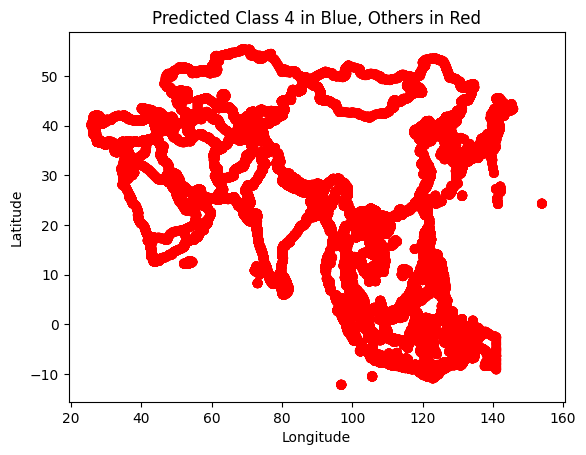

In [53]:
def predict(model, X):
    with torch.no_grad():
        logits = model(torch.tensor(X))
        preds = torch.argmax(logits, axis=1).numpy()
    return preds

# After training, get predictions
preds = predict(model, X)

# Define colors:  
# - Blue if predicted class is 4  
# - Red otherwise
colors = ['blue' if p == 4 else 'red' for p in preds]

# Plot all coordinates with corresponding colors
plt.scatter(X[:, 0], X[:, 1], c=colors)
plt.title('Predicted Class 4 in Blue, Others in Red')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [ ]:
dataloader = DataLoader(dataset, batch_size=36, shuffle=True)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [88]:
for epoch in range(200):
    total_loss = 0
    num_batches = 0

    for batch_X, batch_y in dataloader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    avg_loss = total_loss / num_batches
    print(f'Epoch {epoch + 1}/{200}, Average Loss: {avg_loss:.4f}')


Epoch 1/200, Average Loss: 2.7782
Epoch 2/200, Average Loss: 2.7755
Epoch 3/200, Average Loss: 2.7760
Epoch 4/200, Average Loss: 2.7766
Epoch 5/200, Average Loss: 2.7775
Epoch 6/200, Average Loss: 2.7762
Epoch 7/200, Average Loss: 2.7758
Epoch 8/200, Average Loss: 2.7753


KeyboardInterrupt: 

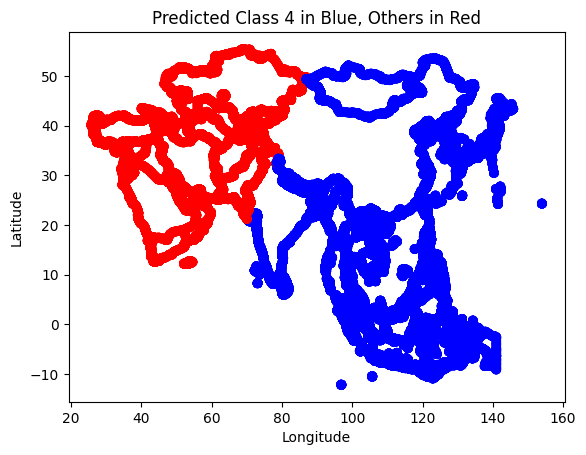

In [89]:
def predict(model, X):
    with torch.no_grad():
        logits = model(torch.tensor(X))
        preds = torch.argmax(logits, axis=1).numpy()
    return preds

# After training, get predictions
preds = predict(model, X)

# Define colors:  
# - Blue if predicted class is 4  
# - Red otherwise
colors = ['blue' if p == 4 else 'red' for p in preds]

# Plot all coordinates with corresponding colors
plt.scatter(X[:, 0], X[:, 1], c=colors)
plt.title('Predicted Class 4 in Blue, Others in Red')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()